In [1]:
# IMPORT LIBRARIES

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os

os.makedirs("charts", exist_ok=True)

In [2]:
# READ CSV FILE

df = pd.read_csv("students.csv")

df.head()

,name,study_hours,sleep_hours,attendance_pct,score,passed
0,Aarav,6.5,7.2,88,82,Yes
1,Sophia,4.0,6.8,75,65,Yes
2,Liam,2.5,5.9,60,45,Yes
3,Emma,8.0,7.5,95,94,Yes
4,Noah,1.5,6.0,55,38,No


In [3]:
# BASIC EDA

print(df.head())

print("\nShape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistics:")
print(df.describe())

     name  study_hours  sleep_hours  attendance_pct  score passed
0   Aarav          6.5          7.2              88     82    Yes
1  Sophia          4.0          6.8              75     65    Yes
2    Liam          2.5          5.9              60     45    Yes
3    Emma          8.0          7.5              95     94    Yes
4    Noah          1.5          6.0              55     38     No

Shape:
(50, 6)

Data Types:
name               object
study_hours       float64
sleep_hours       float64
attendance_pct      int64
score               int64
passed             object
dtype: object

Missing Values:
name              0
study_hours       0
sleep_hours       0
attendance_pct    0
score             0
passed            0
dtype: int64

Statistics:
       study_hours  sleep_hours  attendance_pct      score
count    50.000000    50.000000       50.000000  50.000000
mean      5.082000     6.826000       78.140000  69.240000
std       2.341262     0.841236       14.777272  21.100885
min   

In [4]:
# CONVERT PASSED TO NUMERIC

df["passed_numeric"] = df["passed"].map({
    "Yes": 1,
    "No": 0
})

df.head()

,name,study_hours,sleep_hours,attendance_pct,score,passed,passed_numeric
0,Aarav,6.5,7.2,88,82,Yes,1
1,Sophia,4.0,6.8,75,65,Yes,1
2,Liam,2.5,5.9,60,45,Yes,1
3,Emma,8.0,7.5,95,94,Yes,1
4,Noah,1.5,6.0,55,38,No,0


In [5]:
# CORRELATION MATRIX

correlation_matrix = df.corr(numeric_only=True)

print(correlation_matrix)

                study_hours  sleep_hours  attendance_pct     score  \
study_hours        1.000000     0.950318        0.982511  0.990657   
sleep_hours        0.950318     1.000000        0.957137  0.960103   
attendance_pct     0.982511     0.957137        1.000000  0.995252   
score              0.990657     0.960103        0.995252  1.000000   
passed_numeric     0.515159     0.522747        0.577402  0.562343   

                passed_numeric  
study_hours           0.515159  
sleep_hours           0.522747  
attendance_pct        0.577402  
score                 0.562343  
passed_numeric        1.000000  


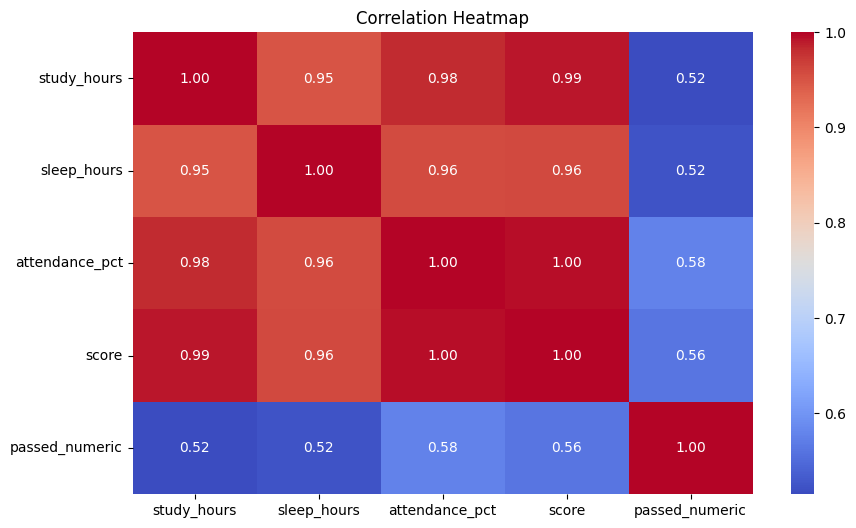

In [6]:
# HEATMAP

plt.figure(figsize=(10,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.savefig("charts/heatmap.png")

plt.show()

In [7]:
# TOP 3 STRONGEST CORRELATIONS

corr_pairs = correlation_matrix.unstack()

corr_pairs = corr_pairs[corr_pairs != 1]

corr_pairs = corr_pairs.drop_duplicates()

strongest = corr_pairs.reindex(
    corr_pairs.abs().sort_values(ascending=False).index
)

print("Top 3 Strongest Correlations:")
print(strongest.head(3))

Top 3 Strongest Correlations:
attendance_pct  score             0.995252
study_hours     score             0.990657
                attendance_pct    0.982511
dtype: float64


In [8]:
# TOP 3 WEAKEST CORRELATIONS

weakest = corr_pairs.reindex(
    corr_pairs.abs().sort_values().index
)

print("Top 3 Weakest Correlations:")
print(weakest.head(3))

Top 3 Weakest Correlations:
study_hours  passed_numeric    0.515159
sleep_hours  passed_numeric    0.522747
score        passed_numeric    0.562343
dtype: float64


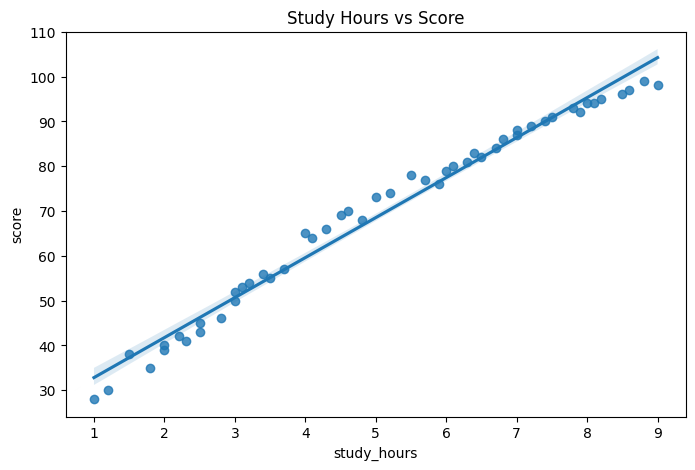

In [9]:
# SCATTER PLOT 1

plt.figure(figsize=(8,5))

sns.regplot(
    x="study_hours",
    y="score",
    data=df
)

plt.title("Study Hours vs Score")

plt.savefig("charts/scatter_plot_1.png")

plt.show()

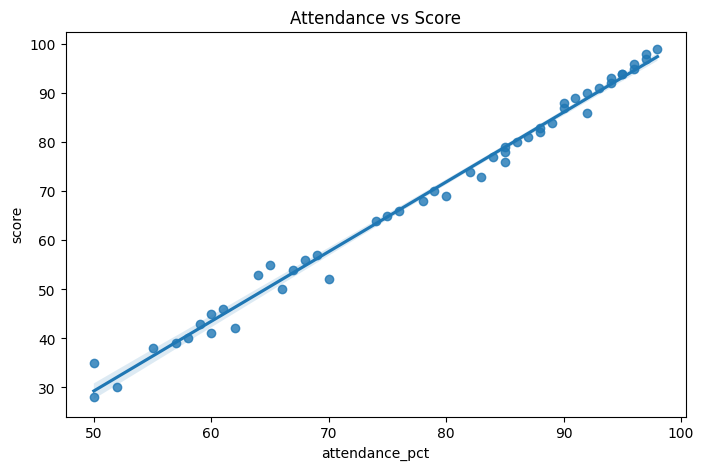

In [10]:
# SCATTER PLOT 2

plt.figure(figsize=(8,5))

sns.regplot(
    x="attendance_pct",
    y="score",
    data=df
)

plt.title("Attendance vs Score")

plt.savefig("charts/scatter_plot_2.png")

plt.show()

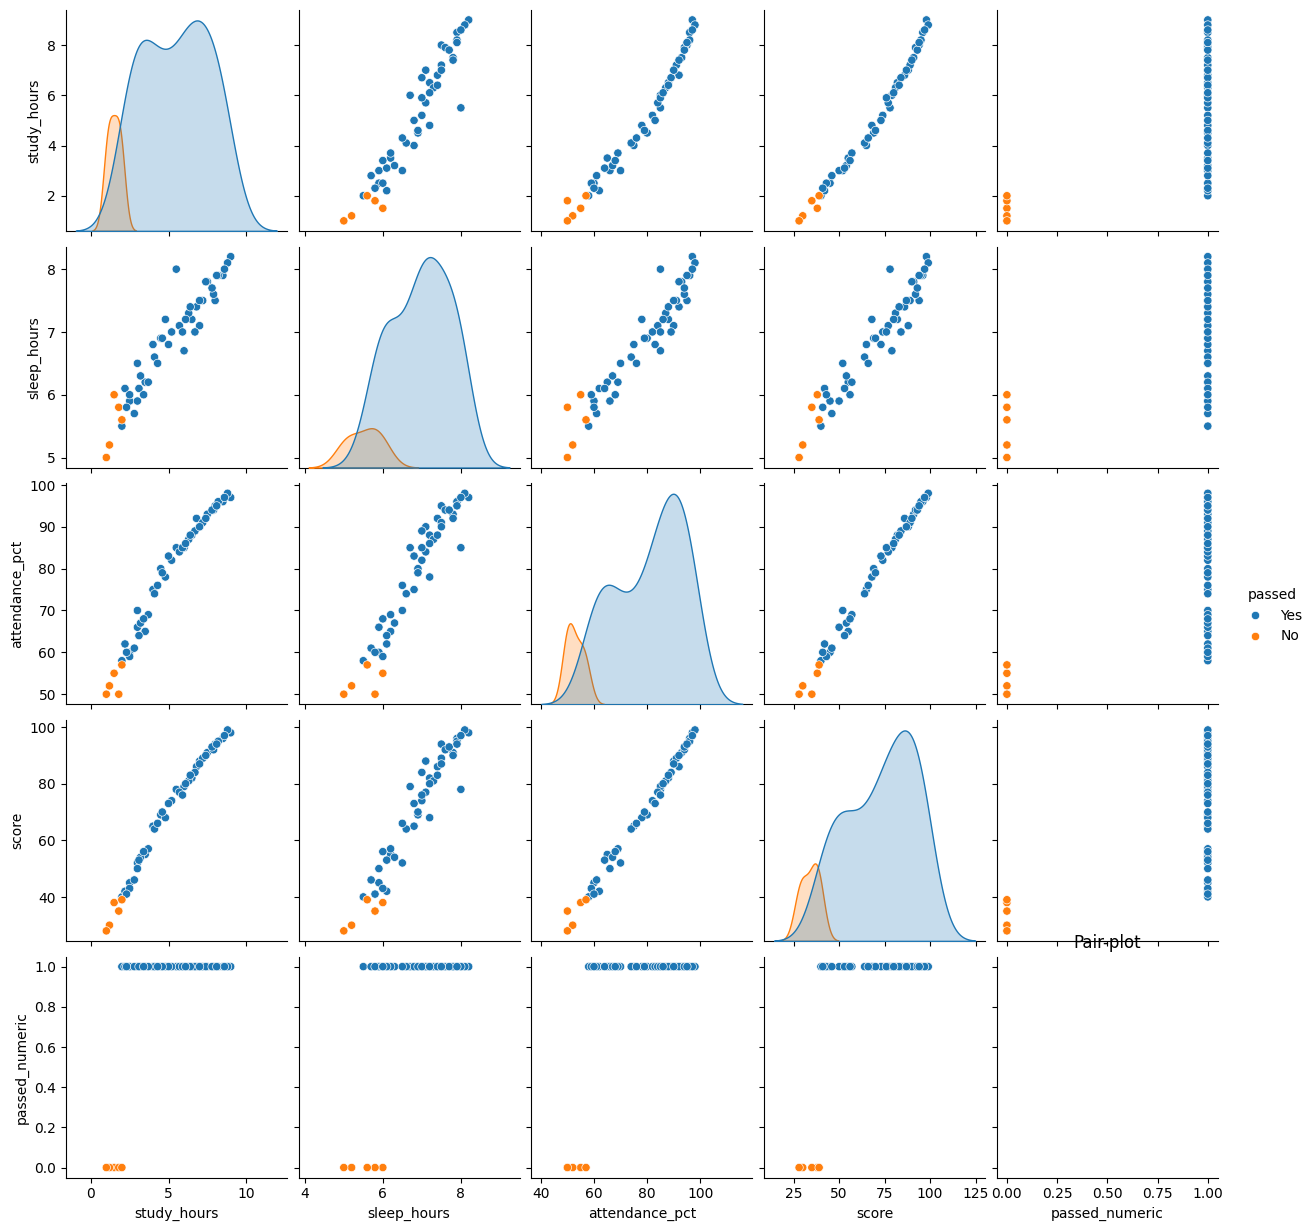

In [11]:
# BONUS PAIRPLOT

sns.pairplot(df, hue="passed")

plt.title("Pair-plot")

plt.savefig("charts/pairplot.png")

plt.show()

In [12]:
# WRITTEN ANALYSIS

print("""
Analysis:

1. Students who study more generally score higher.
2. Attendance has a strong positive effect on scores.
3. Sleep hours have moderate influence.
4. More study does not always guarantee higher scores.
5. Noise and variation make the dataset realistic.
6. Passed students form visible clusters in the pairplot.
""")


Analysis:

1. Students who study more generally score higher.
2. Attendance has a strong positive effect on scores.
3. Sleep hours have moderate influence.
4. More study does not always guarantee higher scores.
5. Noise and variation make the dataset realistic.
6. Passed students form visible clusters in the pairplot.

